# Optimal transport — exercises

Companion notebook to *A beginner course in optimal transport*. Twelve exercises spanning the eight modules of the course. **Solutions are intentionally omitted.** Work through them in order; the later ones build on machinery from the earlier ones.

## How to use this notebook

- Each exercise is preceded by a brief restatement of the relevant theory and a code scaffold.
- Cells marked `# YOUR CODE HERE` are where you fill in.
- Reference solutions exist (they're standard) — but writing your own is the point. If you get stuck for more than ~30 minutes on a single exercise, move on and come back.
- Estimated total time: 10–15 hours, depending on how deep you go on the open-ended bits.

## Conventions used throughout

- $\mu, \nu \in \mathcal{P}(\mathbb{R}^d)$ are probability measures.
- Discrete: $a \in \Delta^{n-1}$, $b \in \Delta^{m-1}$ are weight vectors; $C \in \mathbb{R}_+^{n \times m}$ is the cost matrix.
- $P$ is a transport plan: $P \mathbf{1} = a$, $P^\top \mathbf{1} = b$, $P_{ij} \geq 0$.
- $W_p$: Wasserstein-$p$ distance with $c(x,y) = \|x - y\|^p$.

## Setup

You'll need: `numpy`, `scipy`, `matplotlib`, `POT` (`pip install POT`), and `scikit-learn` for one of the application exercises. PyTorch is optional and only used for the WGAN exercise at the end.




In [1]:
# Setup — run this first
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from scipy.spatial.distance import cdist

# POT
import ot

# sklearn (used in Exercise 10)
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression

rng = np.random.default_rng(42)

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print(f"NumPy {np.__version__}, POT {ot.__version__}")

NumPy 2.0.2, POT 0.9.6.post1


## Exercise 1 — Discrete Kantorovich, by hand

> *Module 1.3 — the LP form of the Kantorovich problem.*

Solve the Kantorovich problem from scratch using `scipy.optimize.linprog`, **without** calling any POT solver. The discrete Kantorovich problem reads

$$\min_{P \in \mathbb{R}_+^{n \times m}} \langle C, P \rangle \quad \text{s.t. } P \mathbf{1}_m = a, \quad P^\top \mathbf{1}_n = b.$$

Linprog wants the LP in the standard form
$$\min c^\top x \quad \text{s.t. } A_{eq}\, x = b_{eq}, \; x \geq 0.$$

**Tasks:**
1. Vectorize $P$ as $x = \mathrm{vec}(P) \in \mathbb{R}^{nm}$ (you choose row-major or column-major; be consistent).
2. Build $A_{eq}$ and $b_{eq}$ that encode the marginal constraints.
3. Solve and reshape $x$ back into $P$.
4. Verify against `ot.emd` on a random instance with $n = 6, m = 8$.

**Open question:** what is the rank of $A_{eq}$? Why is one constraint redundant?



In [6]:
def kantorovich_lp(a, b, C):
    # Solve the Kantorovich LP: min <C, P> s.t. P 1 = a, P^T 1 = b, P >= 0.
    # Return the optimal plan P with shape (len(a), len(b)).
    n, m = len(a), len(b)

    # Decision variable x = vec(P) in row-major (C order): x[i*m + j] = P[i, j]
    c = C.reshape(n * m, order="C")

    # Build A_eq x = b_eq encoding row/col sums.
    A_eq = np.zeros((n + m, n * m))

    # Row constraints: sum_j P[i, j] = a[i]
    for i in range(n):
        A_eq[i, i*m:(i+1)*m] = 1.0
    
    # Column constraints: sum_i P[i, j] = b[j]
    for j in range(m):
        A_eq[n+j, j::m] = 1.0
        
    b_eq = np.concatenate([a, b])

    res = linprog(
        c=c,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=(0, None),
        method="highs",
    )
    if not res.success:
        raise RuntimeError(f"linprog failed: {res.message}")
    #print the rank of A_eq
    print("A_eq dim: ", A_eq.shape, "; A_eq rank:", np.linalg.matrix_rank(A_eq))
    P = res.x.reshape(n, m, order="C")
    return P

# Test instance
n, m = 6, 8
a = rng.dirichlet(np.ones(n))
b = rng.dirichlet(np.ones(m))
xs = rng.normal(size=(n, 2))
xt = rng.normal(loc=2.0, size=(m, 2))
C = cdist(xs, xt, metric="sqeuclidean")

# Compare against POT's exact solver
P_pot = ot.emd(a, b, C)
P_mine = kantorovich_lp(a, b, C)
print("Max abs difference:", np.abs(P_mine - P_pot).max())
print("Cost (mine, POT):", (P_mine * C).sum(), (P_pot * C).sum())



A_eq dim:  (14, 48) ; A_eq rank: 13
Max abs difference: 6.938893903907228e-17
Cost (mine, POT): 18.278943415115485 18.278943415115478


## Exercise 2 — One-dimensional OT and the comonotone coupling

> *Module 1, special case.*

In 1D with cost $c(x,y) = |x-y|^p$ for $p \geq 1$, the optimal coupling has a closed-form characterization: it is the **comonotone** (also called *non-decreasing rearrangement*) coupling. For empirical distributions with equal weights and equal sample sizes, this means: sort both samples, match them in order.

**Tasks:**
1. Sample $n = 1000$ points $x \sim \mathcal{N}(0, 1)$ and $y \sim \mathcal{N}(2, 1.5^2)$. Compute the squared $W_2$ distance two ways:
   - Via `ot.emd` on the full $n \times n$ cost matrix.
   - Via the sorted-matching shortcut $\frac{1}{n} \sum_i (x_{(i)} - y_{(i)})^2$.
2. Time both. The shortcut should be vastly faster.
3. Compare both empirical estimates against the closed-form $W_2^2$ between Gaussians (you'll derive it in Exercise 3 — for now, look it up: $(m_1 - m_2)^2 + (\sigma_1 - \sigma_2)^2$).
4. **Why does sorting work?** Write a 2-3 sentence argument using $c$-cyclical monotonicity (Module 3.3). When does this break?



In [10]:
# YOUR CODE HERE
# Generate the samples, compute both estimates, time them, plot a small comparison.
# Method 1, using ot.emd
from time import perf_counter
from math import sqrt

start_time = perf_counter()

x = np.random.normal(0, 1, 1000)
y = np.random.normal(2, 1.5, 1000)
C = cdist(x[:, None], y[:, None], metric="sqeuclidean")
a = rng.dirichlet(np.ones(1000))
b = rng.dirichlet(np.ones(1000))
w2_emd = ot.emd2(a, b, C)
time_emd = perf_counter() - start_time

# Method 2, via sorted matching
start_time = perf_counter()
x_sorted = np.sort(x)
y_sorted = np.sort(y)
w2_sorted = np.mean((x_sorted - y_sorted) ** 2)
time_sorted = perf_counter() - start_time

w2_bures = (2 - 0) ** 2 + 1.5**2 +1 - 2 * sqrt(1.5**2)

#Compare the two methods
print(f"W2^2 via random coupling: {w2_emd}")
print(f"W2^2 via sorted matching: {w2_sorted}")
print (f"W2^2 via Bures Formula: {w2_bures}")
#Time the two methods
print(f"Time taken by ot.emd: {time_emd} seconds")
print(f"Time taken by sorted matching: {time_sorted} seconds")


W2^2 via random coupling: 4.373068242983121
W2^2 via sorted matching: 4.603529227549822
W2^2 via Bures Formula: 4.25
Time taken by ot.emd: 0.11400787499951548 seconds
Time taken by sorted matching: 0.00013737500012211967 seconds


## Exercise 3 — $W_2$ between Gaussians (the Bures formula)

> *Module 2, Exercise 2.1.*

For Gaussians $\mu = \mathcal{N}(m_1, \Sigma_1)$ and $\nu = \mathcal{N}(m_2, \Sigma_2)$ on $\mathbb{R}^d$,

$$W_2^2(\mu, \nu) = \|m_1 - m_2\|^2 + \mathrm{tr}\Bigl(\Sigma_1 + \Sigma_2 - 2\bigl(\Sigma_1^{1/2} \Sigma_2 \Sigma_1^{1/2}\bigr)^{1/2}\Bigr).$$

**Tasks:**
1. Implement the Bures formula `bures_w2(m1, S1, m2, S2)`. Use `scipy.linalg.sqrtm` for matrix square roots.
2. Pick $d = 5$, sample $\Sigma_1, \Sigma_2$ as random PSD matrices and pick random means.
3. For sample sizes $n \in \{50, 200, 1000, 5000\}$, draw $n$ samples from each Gaussian and compute the empirical $W_2$ via POT. Plot the empirical estimate vs $n$ on a log-x axis with the closed-form value as a horizontal line.
4. The empirical estimator is **biased** for finite $n$ (it converges from above at rate $n^{-1/d}$ for $d > 4$). Comment on what you see in your plot.



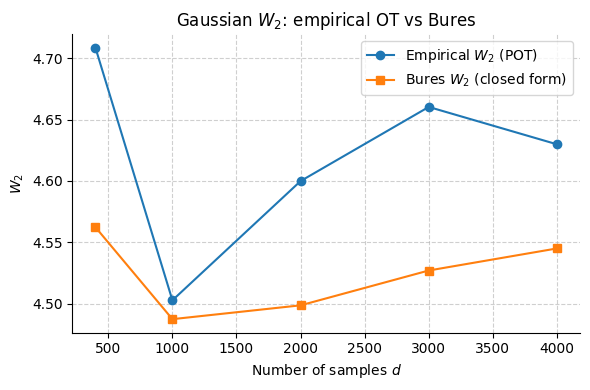

In [32]:
from scipy.linalg import sqrtm
from math import sqrt

def bures_w2(m1, S1, m2, S2):
    # Closed-form squared W_2 between two Gaussians.
    # YOUR CODE HERE
    A = sqrtm(S1)
    B = sqrtm(A @ S2 @ A)
    w2_sq = np.linalg.norm(m1-m2)**2 + np.trace(S1 + S2 - 2*B)
    return float(sqrt(np.real(w2_sq)))

def bures_w2_diag(m1, S1, m2, S2):
    # Closed-form squared W_2 between two Gaussians with diagonal covariance matrices.
    # YOUR CODE HERE
    w2_sq = np.linalg.norm(m1-m2)**2 + np.sum(S1 + S2 - 2*np.sqrt(S1*S2))
    return float(sqrt(np.real(w2_sq)))

n = 5
#vary d
d = [400,1000, 2000,3000,4000]
w2_emd = []
w2_bures = []
for d_ in d:
    m1 = np.zeros(n)
    m2 = np.ones(n)*2
    S1 = rng.uniform(0.5, 2.0, size=n)
    S2 = rng.uniform(0.5, 2.0, size=n)
    #W2 via Bures fomula
    w2_bures.append(bures_w2_diag(m1, S1, m2, S2))
    #empirical W2 via POT
    x1 = rng.multivariate_normal(m1, np.diag(S1), size=(d_))
    x2 = rng.multivariate_normal(m2, np.diag(S2), size=(d_))
    a = np.ones(d_)/d_
    b = np.ones(d_)/d_
    C = cdist(x1, x2, metric="sqeuclidean")
    w2 = ot.emd2(a, b, C)
    w2_emd.append(sqrt(w2))
#make plots with subfigure

fig, ax = plt.subplots(figsize=(6, 4))

n_list = np.asarray(d, dtype=float)

ax.plot(n_list, w2_emd, "o-", color="tab:blue", label=r"Empirical $W_2$ (POT)")

# Bures: often a constant horizontal reference line
wb = np.asarray(w2_bures, dtype=float).ravel()
if wb.size == 1:
    ax.axhline(wb[0], color="tab:orange", ls="--", lw=2, label=r"Bures $W_2$ (closed form)")
else:
    ax.plot(n_list, wb, "s-", color="tab:orange", label=r"Bures $W_2$ (closed form)")

ax.set_xlabel(r"Number of samples $d$")
ax.set_ylabel(r"$W_2$")
ax.set_title(r"Gaussian $W_2$: empirical OT vs Bures")
ax.grid(True, which="both", ls="--", alpha=0.6)
ax.legend()
plt.tight_layout()


## Exercise 4 — Geometry awareness: $W_1$ versus KL

> *Module 0, motivating example.*

Recreate the foundational plot showing why $W_1$ is well-behaved on Diracs. Let $\mu = \delta_0$ and $\nu_\theta = \delta_\theta$ for $\theta \in [-3, 3]$.

**Tasks:**
1. Compute (analytically — no code needed for this one) and tabulate $W_1(\mu, \nu_\theta)$, $\mathrm{TV}(\mu, \nu_\theta)$, $\mathrm{JS}(\mu, \nu_\theta)$, $\mathrm{KL}(\mu \| \nu_\theta)$ as functions of $\theta$.
2. Now consider Gaussians $\mu = \mathcal{N}(0, \sigma^2)$ and $\nu_\theta = \mathcal{N}(\theta, \sigma^2)$ with $\sigma = 0.05$ (so they are nearly Diracs). Plot the four divergences as functions of $\theta$ on the same axes.
3. Explain what you see. Why is $W_1$ uniquely useful for gradient-based optimization here? (This is exactly the WGAN motivation, Module 6.1.)



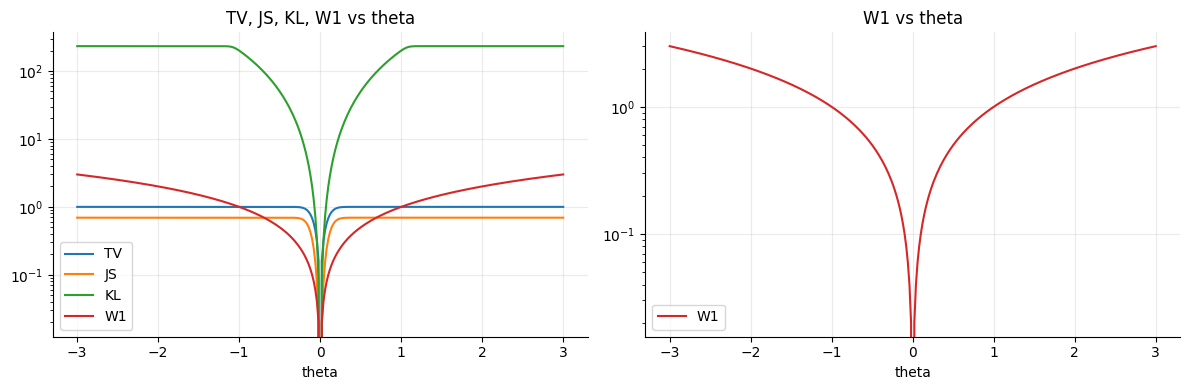

In [39]:
#Question 1 responses:
#W1 : abs(theta) 
#TV : 0
#JS : log(2) if theta <> 0
#KL : inf

# YOUR CODE HERE — compute and plot the four divergences for nearly-Dirac Gaussians.
import numpy as np
import matplotlib.pyplot as plt

sigma = 0.05
theta = np.linspace(-3, 3, 301)
eps = 1e-100
# x-grid wide enough to cover both Gaussians
x = np.linspace(-3.5, 3.5, 20000)
dx = x[1] - x[0]

def normal_pdf(x, m, s):
    return (1/(s*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-m)/s)**2)

W1_values, TV_values, JS_values, KL_values = [], [], [], []

for t in theta:
    p = normal_pdf(x, 0.0, sigma)
    q = normal_pdf(x, t, sigma)
    m = 0.5 * (p + q)

    # W1 in 1D for equal-variance shift: |t|
    W1 = abs(t)

    # TV, KL and JS: Ensure nonzero entries
    p_clipped = np.maximum(p, eps)
    q_clipped = np.maximum(q, eps)
    m_clipped = np.maximum(m, eps)

    TV = 0.5 * np.sum(np.abs(p - q)) * dx
    # KL(p||q)
    KL = np.sum(p_clipped * (np.log(p_clipped) - np.log(q_clipped))) * dx
    # JS(p,q)
    JS = (
        0.5 * np.sum(p_clipped * (np.log(p_clipped) - np.log(m_clipped))) * dx +
        0.5 * np.sum(q_clipped * (np.log(q_clipped) - np.log(m_clipped))) * dx
    )

    W1_values.append(W1)
    TV_values.append(TV)
    JS_values.append(JS)
    KL_values.append(KL)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left subplot: all divergences (except W1)
axes[0].plot(theta, TV_values, label="TV")
axes[0].plot(theta, JS_values, label="JS")
axes[0].plot(theta, KL_values, label="KL")
axes[0].plot(theta, W1_values, label="W1")
axes[0].set_xlabel("theta")
axes[0].set_yscale("log")  # KL can blow up fast
axes[0].set_title("TV, JS, KL, W1 vs theta")
axes[0].legend()

# Right subplot: W1 only
axes[1].plot(theta, W1_values, label="W1", color="tab:red")
axes[1].set_xlabel("theta")
axes[1].set_yscale("log")
axes[1].set_title("W1 vs theta")
axes[1].legend()

plt.tight_layout()
plt.show()

# Hints:
#   - For Gaussians, KL has a closed form.
#   - For nearly-Dirac Gaussians, you can either compute on a fine 1D grid or use closed forms.
#   - Plot W_1, TV, JS, KL on the same axes (consider log scale on the y axis).


## Exercise 5 — Triangle inequality, empirically

> *Module 2.1.*

The triangle inequality $W_p(\mu, \nu) \leq W_p(\mu, \rho) + W_p(\rho, \nu)$ is the deepest property to prove (the "gluing lemma"). Verify it numerically.

**Tasks:**
1. Pick three random Gaussians $\mu, \rho, \nu$ in $\mathbb{R}^4$ with random means and covariances.
2. Sample $n = 500$ points from each and compute all three $W_2$ distances using POT.
3. Verify $W_2(\mu, \nu) \leq W_2(\mu, \rho) + W_2(\rho, \nu)$.
4. Repeat 100 times with random configurations and plot a histogram of the slack $W_2(\mu, \rho) + W_2(\rho, \nu) - W_2(\mu, \nu)$. It should be non-negative.
5. **When is the inequality tight?** Construct a configuration where it is exactly tight (or arbitrarily close).


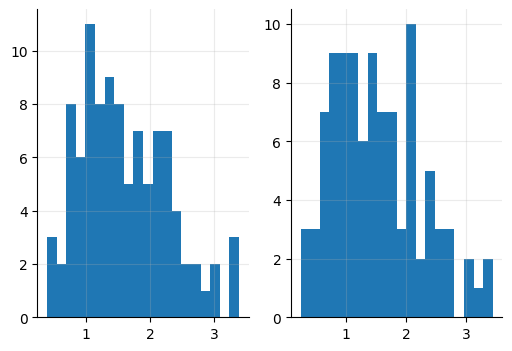

In [41]:
# YOUR CODE HERE
n = 4
d = 500
w2_slack_empirical, w2_slack_closed_form = [], []
a = np.ones(d)/d
b = np.ones(d)/d
for i in range(100):
    mu_mean = np.random.uniform(-1, 1, size=n)
    mu_cov = np.eye(n) * np.random.uniform(0.1, 1, size=n)
    rho_mean = np.random.uniform(-1, 1, size=n)
    rho_cov = np.eye(n) * np.random.uniform(0.1, 1, size=n)
    nu_mean = np.random.uniform(-1, 1, size=n)
    nu_cov = np.eye(n) * np.random.uniform(0.1, 1, size=n)
    mu = np.random.multivariate_normal(mu_mean, mu_cov, size=d)
    rho = np.random.multivariate_normal(rho_mean, rho_cov, size=d)
    nu = np.random.multivariate_normal(nu_mean, nu_cov, size=d)
    #Compute empirical W2 distances
    C1 = cdist(mu, rho, metric="sqeuclidean")
    C2 = cdist(rho, nu, metric="sqeuclidean")
    C3 = cdist(mu, nu, metric="sqeuclidean")
    W1 = np.sqrt(ot.emd2(a, b, C1))
    W2 = np.sqrt(ot.emd2(a, b, C2))
    W3 = np.sqrt(ot.emd2(a, b, C3))
    #verify the triangle inequality
    W2_mu_rho = bures_w2(mu_mean, mu_cov, rho_mean, rho_cov)
    W2_rho_nu = bures_w2(rho_mean, rho_cov, nu_mean, nu_cov)
    W2_mu_nu = bures_w2(mu_mean, mu_cov, nu_mean, nu_cov)
    w2_slack_empirical.append(W1 + W2 - W3)
    w2_slack_closed_form.append(W2_mu_rho + W2_rho_nu - W2_mu_nu)
plt.subplot(1,2,1)
plt.hist(w2_slack_empirical, bins=20, label="empirical")
plt.subplot(1,2,2)
plt.hist(w2_slack_closed_form, bins=20, label="closed form")
plt.show()


(500, 500)


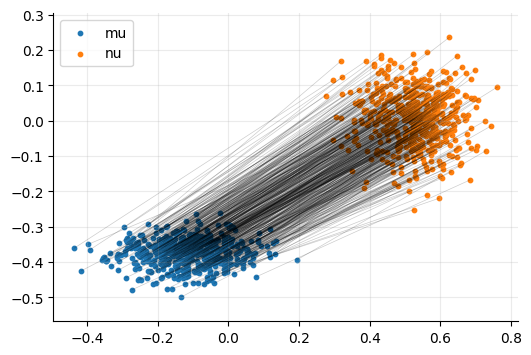

(500, 500)


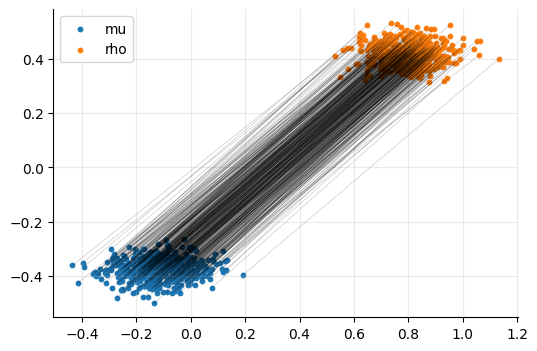

(500, 500)


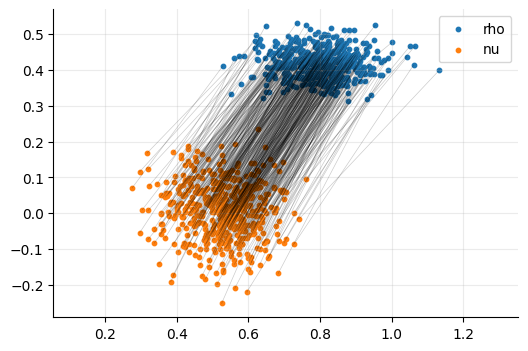

In [7]:
#Plot coupling 2d
def coupling_plan(X,Y):
    C = cdist(X,Y, metric="sqeuclidean")
    P = ot.emd(a, b, C)
    return P

def plot_coupling_plan(P,X,Y,k=500,lw=0.5,label=None,dist1=None,dist2=None):
    plt.scatter(X[:,0], X[:,1], s=10, label=dist1)
    plt.scatter(Y[:,0], Y[:,1], s=10, label=dist2)
    # draw only the k largest-mass edges (otherwise it's too dense)
    print(P.shape)
    idx = np.dstack(np.unravel_index(np.argsort(P.ravel())[::-1], P.shape))[0]
    for (i, j) in idx[:k]:
        if P[i, j] <= 0: 
            break
        plt.plot([X[i,0], Y[j,0]], [X[i,1], Y[j,1]], "k-", alpha=0.2, lw=lw, label=label)
    plt.legend()
    plt.axis("equal")
    plt.show()

n = 4
w2_slack_empirical, w2_slack_closed_form = [], []
a = np.ones(500)/500
b = np.ones(500)/500
for i in range(1000):
    mu_mean = np.random.uniform(-1, 1, size=n)
    mu_cov = np.eye(n) * np.random.uniform(0.001, 0.01, size=n)
    rho_mean = np.random.uniform(-1, 1, size=n)
    rho_cov = np.eye(n) * np.random.uniform(0.001, 0.01, size=n)
    nu_mean = np.random.uniform(-1, 1, size=n)
    nu_cov = np.eye(n) * np.random.uniform(0.001, 0.01, size=n)
    mu = np.random.multivariate_normal(mu_mean, mu_cov, size=500)
    rho = np.random.multivariate_normal(rho_mean, rho_cov, size=500)
    nu = np.random.multivariate_normal(nu_mean, nu_cov, size=500)
    P1 = coupling_plan(mu, nu)
    P2 = coupling_plan(mu, rho)
    P3 = coupling_plan(rho, nu)
    plot_coupling_plan(P1, mu, nu,dist1="mu",dist2="nu")
    plot_coupling_plan(P2, mu, rho,dist1="mu",dist2="rho")
    plot_coupling_plan(P3, rho, nu,dist1="rho",dist2="nu")
    break

In [8]:
n = 4
mu_mean = np.zeros(n)
mu_cov = np.eye(n)
rho_mean = np.ones(n) * 0.5
rho_cov = np.eye(n)
nu_mean = np.ones(n)
nu_cov = np.eye(n)

mu = np.random.multivariate_normal(mu_mean, mu_cov, size=500)
rho = np.random.multivariate_normal(rho_mean, rho_cov, size=500)
nu = np.random.multivariate_normal(nu_mean, nu_cov, size=500)

w2_mu_rho = bures_w2(mu_mean, mu_cov, rho_mean, rho_cov)
w2_rho_nu = bures_w2(rho_mean, rho_cov, nu_mean, nu_cov)
w2_mu_nu = bures_w2(mu_mean, mu_cov, nu_mean, nu_cov)

print("Closed-form w2_mu_rho + w2_rho_nu - w2_mu_nu: ", w2_mu_rho + w2_rho_nu - w2_mu_nu)

C_mu_nu = ot.dist(mu, nu, metric="sqeuclidean")
C_mu_ro = ot.dist(mu, rho, metric="sqeuclidean")
C_rho_nu = ot.dist(rho, nu, metric="sqeuclidean")

print(f"mu shape: {mu.shape}, nu shape: {nu.shape}, C_mu_nu shape: {C_mu_nu.shape}")

a,b = np.ones(500)/500, np.ones(500)/500
W_mu_nu = np.sqrt(ot.emd2(a, b, C_mu_nu))
W_mu_ro = np.sqrt(ot.emd2(a, b, C_mu_ro))
W_rho_nu = np.sqrt(ot.emd2(a, b, C_rho_nu))

print("Empirical w2_mu_rho + w2_rho_nu - w2_mu_nu: ", W_mu_ro + W_rho_nu - W_mu_nu)

Closed-form w2_mu_rho + w2_rho_nu - w2_mu_nu:  0.0
mu shape: (500, 4), nu shape: (500, 4), C_mu_nu shape: (500, 500)
Empirical w2_mu_rho + w2_rho_nu - w2_mu_nu:  0.36429668406005744


## Exercise 6 — Kantorovich potentials from the LP solution

> *Module 3.1, 3.3.*

When you solve the discrete primal LP, you get $P^\star$. The dual gives potentials $(\varphi^\star, \psi^\star) \in \mathbb{R}^n \times \mathbb{R}^m$ such that
- $\varphi_i + \psi_j \leq C_{ij}$ for all $i, j$,
- $\varphi_i + \psi_j = C_{ij}$ on $\mathrm{supp}(P^\star)$,
- $\sum_i a_i \varphi_i + \sum_j b_j \psi_j = \langle C, P^\star \rangle$.

**Tasks:**
1. Run `P, log = ot.emd(a, b, C, log=True)` and extract the dual potentials from `log['u']`, `log['v']` (POT's convention).
2. Verify all three conditions above on a random instance. Find the indices where the support of $P$ is non-zero and check the equality $\varphi_i + \psi_j = C_{ij}$ holds to numerical precision.
3. Plot the active constraints: scatter $C_{ij}$ vs $\varphi_i + \psi_j$ for all $(i,j)$, color-coding by whether $P_{ij} > 0$. The active points should fall on the diagonal.


0


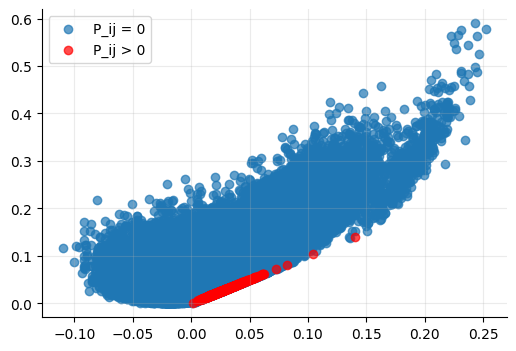

In [ ]:
# YOUR CODE HERE
n, d = 5, 500
mu_mean, mu_cov = rng.uniform(-0.1,0.1, size=n), np.eye(n) * rng.uniform(0.1,1,size=n)
nu_mean, nu_cov = rng.uniform(-0.1,0.1, size=n), np.eye(n) * rng.uniform(0.1,1,size=n)
mu , nu = rng.multivariate_normal(mu_mean, mu_cov, size=d), rng.multivariate_normal(nu_mean, nu_cov, size=d)
C = ot.dist(mu, nu, metric="sqeuclidean")
P, log = ot.emd(a, b, C, log=True)

S = log['u'][:,None] + log['v'][None,:]
tol = 1e-6
print(((S-C)>tol).sum()) #should be 0
#find where P is non zero
non_zero_idx = np.where(P>0)
assert((S[non_zero_idx] - C[non_zero_idx] < tol).all())
# Use non_zero_idx as a mask for highlighting in the scatter plot
mask = np.zeros_like(P, dtype=bool)
mask[non_zero_idx] = True
plt.scatter(S[~mask], C[~mask], label="P_ij = 0", alpha=0.7)
plt.scatter(S[mask], C[mask], color='red', label="P_ij > 0", alpha=0.7)
plt.legend()

## Exercise 7 — Sinkhorn from scratch

> *Module 4.2.*

Implement Sinkhorn's algorithm in pure NumPy. Given $a, b, C, \varepsilon$:

```
K_ij = exp(-C_ij / eps)
u, v = ones(n), ones(m)
for t in 0 .. T-1:
    u = a / (K @ v)
    v = b / (K.T @ u)
P = diag(u) @ K @ diag(v)
```

**Tasks:**
1. Implement `sinkhorn(a, b, C, eps, n_iter=1000, tol=1e-9)` returning `(P, log)` where `log` records marginal residuals at each iteration.
2. Test against `ot.sinkhorn` on a random instance with $\varepsilon = 0.1$. Match to within `1e-6`.
3. Plot the marginal residual $\|P \mathbf{1} - a\|_\infty$ as a function of iteration on a log-y scale, for $\varepsilon \in \{0.01, 0.1, 1.0\}$. Linear convergence shows up as a straight line on this plot.
4. **Failure mode:** push $\varepsilon$ to `1e-3`. What goes wrong? (You'll fix it in the next exercise.)


6.409736705188795e-07


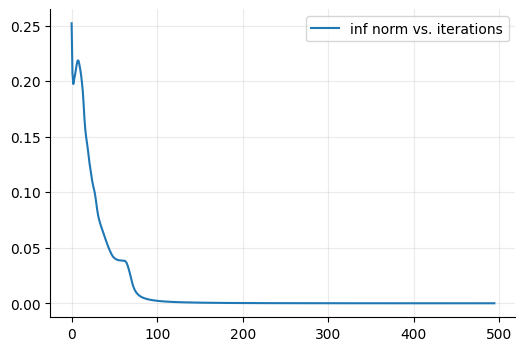

/var/folders/_2/ds89d8td7ns3n2lrj_0j7t200000gn/T/ipykernel_1510/962159800.py:10: RuntimeWarning: divide by zero encountered in divide
  u_1 = a / (K @ v_0)
/var/folders/_2/ds89d8td7ns3n2lrj_0j7t200000gn/T/ipykernel_1510/962159800.py:11: RuntimeWarning: invalid value encountered in matmul
  v_1 = b / (K.T @ u_1)


Transport plan contains NaNs!


In [54]:
def sinkhorn(a, b, C, eps, n_iter=5000, tol=1e-6):
    # Naive (non-stabilized) Sinkhorn.
    # YOUR CODE HERE
    K = np.exp(-C/eps)
    u_0 = np.ones(len(a))
    v_0 = np.ones(len(b))
    counter = 0
    log = {}
    while(counter < n_iter):
        u_1 = a / (K @ v_0)
        v_1 = b / (K.T @ u_1)
        P_ = np.diag(u_1) @ K @ np.diag(v_1)
        counter += 1
        if (np.max(np.abs(P_.sum(axis=1) - a))< tol and np.max(np.abs(P_.sum(axis=0) - b))< tol):
            break
        v_0 = v_1
        log['u'], log['v'] = u_1, v_1
        log.setdefault('P', []).append(P_)   
    P = np.diag(u_1) @ K @ np.diag(v_1)
    return P, log

# Test
n, m = 100, 120
a = rng.dirichlet(np.ones(n))
b = rng.dirichlet(np.ones(m))
xs = rng.normal(size=(n, 2))
xt = rng.normal(loc=2.0, size=(m, 2))
C = cdist(xs, xt, metric='sqeuclidean')

# Compare with POT
P_mine, log = sinkhorn(a, b, C, eps=0.1)
P_pot = ot.sinkhorn(a, b, C, reg=0.1)
print(np.abs(P_mine - P_pot).max())

#Part 2 : Marginal residual
log_P = log['P']
norms = np.max(np.array([np.abs(log_P[i].sum(axis=1) - a) for i in range(len(log_P))]),axis=1)
plt.plot(np.arange(len(norms)), norms, label= "inf norm vs. iterations")
plt.legend()
plt.show()

# 3 failure
P_failure, _ = sinkhorn(a, b, C, eps=1e-3)
if np.isnan(P_failure).any():
    print("Transport plan contains NaNs!")
else:
    print(P_failure)


## Exercise 8 — Stabilized log-domain Sinkhorn

> *Module 4.2.*

The naive iteration breaks for small $\varepsilon$ because $K_{ij} = \exp(-C_{ij}/\varepsilon)$ underflows to 0. The fix is to work in **log-domain** with potentials $\varphi = \varepsilon \log u$, $\psi = \varepsilon \log v$:

$$\varphi_i^{(t+1)} = \varepsilon \log a_i - \varepsilon \,\mathrm{logsumexp}_j\!\left(\frac{\psi_j^{(t)} - C_{ij}}{\varepsilon}\right)$$

and the symmetric update for $\psi$.

**Tasks:**
1. Implement `sinkhorn_log(a, b, C, eps, n_iter=1000)` using `scipy.special.logsumexp` (or your own).
2. Recover the plan as $P_{ij} = \exp\!\bigl((\varphi_i + \psi_j - C_{ij})/\varepsilon\bigr)$.
3. Verify it matches `ot.bregman.sinkhorn_log` for $\varepsilon = 1\mathrm{e}{-3}$.
4. Plot the **transport plan** as a heatmap for $\varepsilon \in \{1, 0.1, 0.01, 0.001\}$ on a 1D problem (e.g., the bimodal-vs-unimodal histogram from the course's live demo). Watch the plan condense to the unregularized solution as $\varepsilon \to 0$.


In [58]:
from scipy.special import logsumexp

def sinkhorn_log(a, b, C, eps, n_iter=3000, tol=1e-3):
    # Optimized log-domain Sinkhorn algorithm.
    phi = np.zeros_like(a)
    psi = np.zeros_like(b)
    log_a = np.log(a)
    log_b = np.log(b)
    inv_eps = 1.0 / eps  # Precompute for speed

    for counter in range(1, n_iter + 1):
        phi_new = eps * log_a - eps * logsumexp((psi[None, :] - C) * inv_eps, axis=1)
        psi_new = eps * log_b - eps * logsumexp((phi_new[:, None] - C) * inv_eps, axis=0)

        # Marginals
        log_r = phi_new * inv_eps + logsumexp((psi_new[None, :] - C) * inv_eps, axis=1)
        log_m = psi_new * inv_eps + logsumexp((phi_new[:, None] - C) * inv_eps, axis=0)
        if np.mean(np.abs(log_r - log_a)) < tol and np.mean(np.abs(log_m - log_b)) < tol:
            phi, psi = phi_new, psi_new
            break
        phi, psi = phi_new, psi_new

    P = np.exp((phi[:, None] + psi[None, :] - C) * inv_eps)
    return P, counter

n,m = 100,120
a = rng.dirichlet(np.ones(n))
b = rng.dirichlet(np.ones(m))
P_mine, counter = sinkhorn_log(a,b,C,eps=1e-3)
P_bregman = ot.bregman.sinkhorn_log(a,b,C,reg=1e-3,numItermax=3000, stopThr=1e-3)

print(f"Convergence in {counter} Iterations")
print(np.linalg.norm(P_mine - P_bregman)/np.linalg.norm(P_bregman))    


Convergence in 3000 Iterations
0.5862348847048974


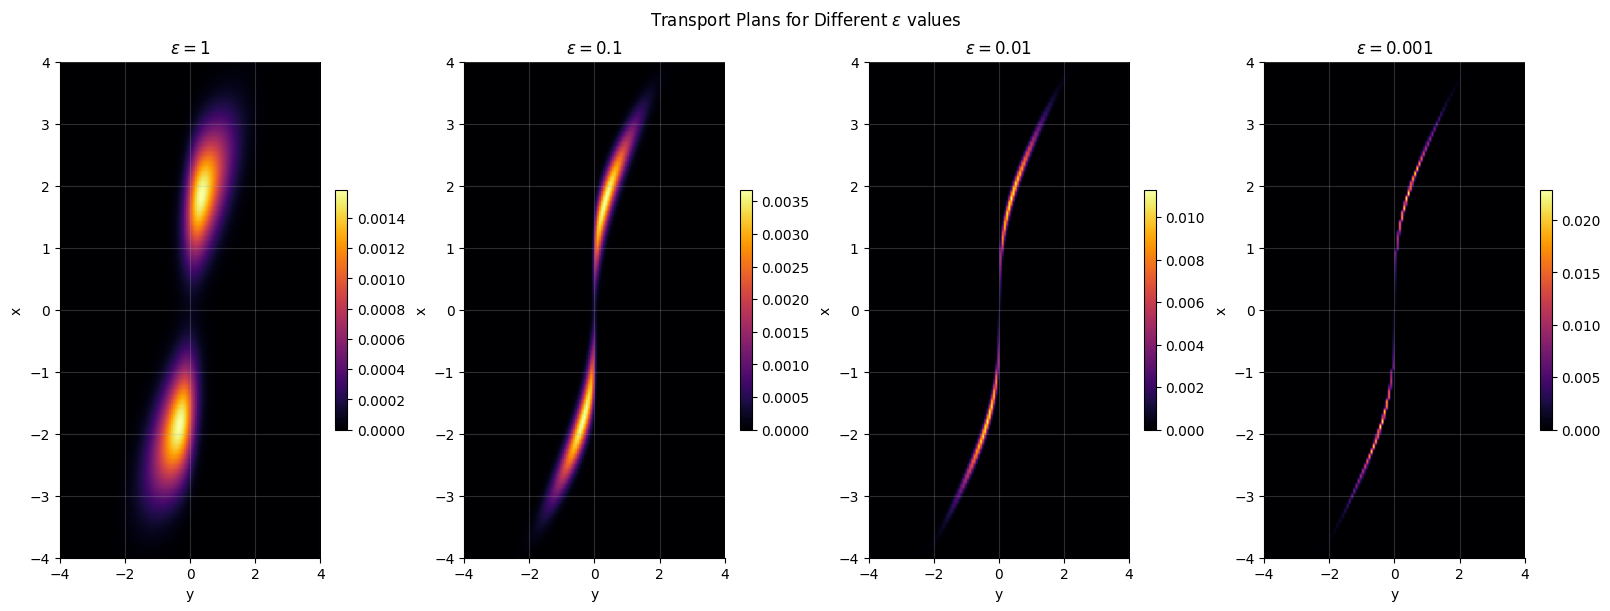

In [59]:
import matplotlib.pyplot as plt

# Prepare a bimodal-vs-unimodal 1D example as in the live demo
n, m = 100, 120
x = np.linspace(-4, 4, n)
y = np.linspace(-4, 4, m)

# Vectorized computation for distributions
exp_x_plus = np.exp(-(x + 2) ** 2)
exp_x_minus = np.exp(-(x - 2) ** 2)
a = 0.5 * (exp_x_plus + exp_x_minus)
a /= a.sum()
b = np.exp(-y ** 2)
b /= b.sum()

# Precompute cost matrix once
C = (x[:, None] - y[None, :]) ** 2

epsilons = [1, 0.1, 0.01, 0.001]
n_eps = len(epsilons)

fig, axs = plt.subplots(1, n_eps, figsize=(4 * n_eps, 6), constrained_layout=True)

# If axs is a single axis (unlikely), force into array shape for uniformity
if n_eps == 1:
    axs = np.array([axs])

for idx, eps in enumerate(epsilons):
    # Compute transport plan with log-domain Sinkhorn implementation
    P, _ = sinkhorn_log(a, b, C, eps, n_iter=3000, tol=1e-3)
    im = axs[idx].imshow(
        P,
        aspect='auto',
        origin='lower',
        extent=[y[0], y[-1], x[0], x[-1]],
        cmap='inferno'
    )
    axs[idx].set_title(rf'$\varepsilon={eps}$')
    axs[idx].set_xlabel('y')
    axs[idx].set_ylabel('x')
    fig.colorbar(im, ax=axs[idx], fraction=0.046, pad=0.04)

fig.suptitle('Transport Plans for Different $\epsilon$ values')
plt.show()

## Exercise 9 — The Sinkhorn divergence

> *Module 4.3.*

The entropic plan is biased: $\mathrm{OT}^\varepsilon(\mu, \mu) > 0$ in general. The **Sinkhorn divergence** debiases it:

$$S_\varepsilon(\mu, \nu) = \mathrm{OT}^\varepsilon(\mu, \nu) - \tfrac{1}{2} \mathrm{OT}^\varepsilon(\mu, \mu) - \tfrac{1}{2} \mathrm{OT}^\varepsilon(\nu, \nu).$$

**Tasks:**
1. Implement `sinkhorn_divergence(xs, xt, eps, n_iter=500)` using your log-domain Sinkhorn from Exercise 8.
2. Verify $S_\varepsilon(\mu, \mu) = 0$ on the same sample.
3. **Asymptotics.** For two well-separated Gaussians, plot $S_\varepsilon$ as a function of $\varepsilon$ on a log-x axis. As $\varepsilon \to 0$, $S_\varepsilon \to W_2^2$. As $\varepsilon \to \infty$, $S_\varepsilon \to \mathrm{MMD}_K^2$ for the kernel $K(x, y) = -\|x-y\|^2/2$. Verify the limits numerically.
4. **Use it as a loss.** Define a tiny generative model: $g_\theta(z) = z + \theta$ where $z \sim \mathcal{N}(0, I_2)$, target = $\mathcal{N}(\mu^\star, I_2)$. Optimize $\theta$ by gradient descent on $S_\varepsilon$ (use POT's autograd-friendly version `ot.sinkhorn2` with the right backend, or finite differences if you skip autograd). Plot the trajectory of $\theta$.


In [13]:
from IPython.display import display, Math

# YOUR CODE HERE
#Implement sinkhorn_divergence
def ot_entropic_value(P,C,eps):
    cost = float(np.sum(P*C))
    mask = P>0
    ent = float(np.sum(P[mask]*(np.log(P[mask])-1.0)))
    return cost + eps*ent

def sinkhorn_log_divergence(a,b,C,eps):
    ot_mu_mu = ot_entropic_value(ot.bregman.sinkhorn_log(a,b,C["mu_nu"],reg=eps,numItermax=6000), C["mu_nu"],eps)
    ot_mu_mu = ot_entropic_value(ot.bregman.sinkhorn_log(a,a,C["mu_mu"],reg=eps,numItermax=6000), C["mu_mu"],eps)
    ot_nu_nu = ot_entropic_value(ot.bregman.sinkhorn_log(b,b,C["nu_nu"],reg=eps,numItermax=6000), C["nu_nu"],eps)

    return  ot_mu_mu - 0.5 * ot_mu_mu  - 0.5 * ot_nu_nu

#Given two distributions:
n,m = 100,120
mu = rng.normal(loc=0.0, size=(n,5))
nu = rng.normal(loc=1.0, size=(m,5))
a=rng.dirichlet(np.ones(n))
b=rng.dirichlet(np.ones(m))

C = {}
C["mu_nu"] = ot.dist(mu,nu,metric="sqeuclidean")
C["mu_mu"] = ot.dist(mu,mu,metric="sqeuclidean")
C["nu_nu"] = ot.dist(nu,nu,metric="sqeuclidean")

eps = 1e-3
#First check that sinkhorn(mu,mu) might not be 0
P = ot.bregman.sinkhorn_log(a,a,C["mu_mu"],reg=eps)
print(f"OT(mu,mu):{ot_entropic_value(P,C['mu_mu'],eps)}")

display(Math(r"S_\varepsilon(\mu, \nu) = {:.4e}".format(sinkhorn_log_divergence(a, b, C, eps))))

OT(mu,mu):-0.005187391964599818


<IPython.core.display.Math object>

/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: divide by zero encountered in divide
  u = 1.0 / nx.dot(Kp, v)
/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 0
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:631: RuntimeWarning: overflow encountered in divide
  u = 1.0 / nx.dot(Kp, v)
/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 173
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:642: UserWarning: Warning: numerical errors at iteration 361
  warnings.warn("Warning: numerical errors at iteration %d" % ii)
/Users/mohamedbaha/Libra

Expected MMD Limit (eps->inf): 10.354171992136937


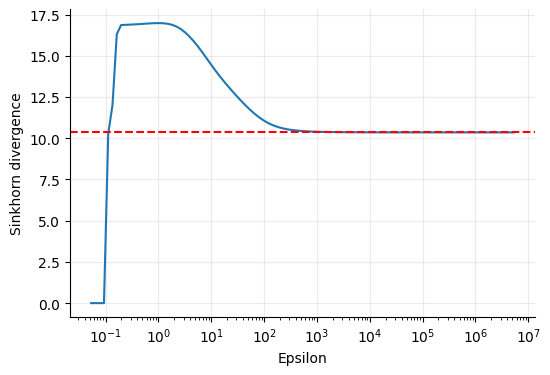

In [89]:
def sinkhorn_divergence(a, b, Cs, eps):
    """Sinkhorn divergence using POT's scalar Sinkhorn cost.

    S_eps(a, b) = OT_eps(a, b) - 0.5 * (OT_eps(a, a) + OT_eps(b, b))

    Notes:
    - `ot.sinkhorn2` returns a scalar regularized OT cost (as defined by POT).
    - Here `Cs` is a dict with keys: "mu_nu", "mu_mu", "nu_nu".
    """
    ot_ab = ot.sinkhorn2(a, b, Cs["mu_nu"], reg=eps, numItermax=6000)
    ot_aa = ot.sinkhorn2(a, a, Cs["mu_mu"], reg=eps, numItermax=6000)
    ot_bb = ot.sinkhorn2(b, b, Cs["nu_nu"], reg=eps, numItermax=6000)
    return ot_ab - 0.5 * (ot_aa + ot_bb)


# Asymptotics: two well-separated Gaussians
n, m, d = 100, 100, 5
A = rng.normal(loc=0.0, scale=1.0, size=(d, d))
cov = A @ A.T + 1e-6 * np.eye(d)

mu = rng.multivariate_normal(mean=np.zeros(d), cov=cov, size=n)
nu = rng.multivariate_normal(mean=np.ones(d), cov=cov, size=m)

# Cost matrices
Cs = {
    "mu_nu": ot.dist(mu, nu, metric="sqeuclidean"),
    "mu_mu": ot.dist(mu, mu, metric="sqeuclidean"),
    "nu_nu": ot.dist(nu, nu, metric="sqeuclidean"),
}

# Use simple uniform weights (more stable than random Dirichlet for demos)
a = np.ones(n) / n
b = np.ones(m) / m

# Sweep eps relative to the cost scale
C_scale = float(np.median(Cs["mu_nu"]))
epsilons = C_scale * np.logspace(-3, 5, 100)
sinkhorn_divergences = [sinkhorn_divergence(a, b, Cs, eps) for eps in epsilons]
mmd_inf = float(np.sum((mu.mean(axis=0) - nu.mean(axis=0))**2))
print("Expected MMD Limit (eps->inf):", mmd_inf)

plt.plot(epsilons, sinkhorn_divergences)
plt.axhline(mmd_inf, color='red', linestyle='--', label='MMD Limit')
plt.xscale("log")
plt.xlabel("Epsilon")
plt.ylabel("Sinkhorn divergence")
plt.show()

In [96]:
import torch
import logging
if not logging.getLogger().hasHandlers():
    logging.basicConfig(level=logging.INFO, format="%(message)s")
log = logging.getLogger("w2_optimization")

#OT simple generative model
n, n_points = 2, 500
cov = torch.tensor(np.eye(n))
target_mean = torch.tensor([-4.0, 4.0], dtype=torch.float32)
z = torch.tensor(rng.multivariate_normal(mean = np.zeros(n), cov = cov, size=n_points))
nu = torch.tensor(rng.multivariate_normal(mean = target_mean, cov = cov, size = n_points))
theta_, thetas_ot, thetas_mse = torch.tensor(rng.uniform(0,0.1,size=n)), [], []
a,b = torch.tensor(rng.dirichlet(np.ones(n_points))), torch.tensor(rng.dirichlet(np.ones(n_points)))

In [77]:
theta = torch.as_tensor(theta_).detach().clone().requires_grad_(True)
optimizer = torch.optim.Adam([theta], lr=1e-2)
tol, n_iter_max, counter_ot, counter = 1e-3, 100, 0,0
eps_start, eps_min, decay = 5e-1, 1e-2, 0.92
patience = 10  # you can choose any reasonable integer
best_norm = float('inf')
patience_counter = 0
grads_norm = []
ot_losses = []
while(1):
    #compute ot between the target and generated distributions
    #compute cost function
    mu = z + theta
    C = torch.cdist(mu,nu) ** 2

    step_log_template = "Step {:03d}: w2 = {:.6f}, |theta - target| = {:.5f}"

    #compute ot.sinkhorn2
    w2 = ot.sinkhorn2(a,b,C,reg=eps,method="sinkhorn_log")
    current_norm = (theta - target_mean).norm().item()
    log.info(step_log_template.format(counter_ot, w2.item(), current_norm))
    #differentiate over theta
    optimizer.zero_grad()
    w2.backward()
    with torch.no_grad():
        theta_ = theta - optimizer.param_groups[0]["lr"] * theta.grad
        grad_norm = torch.norm(theta.grad).item()
        optimizer.step()
        grads_norm.append(grad_norm)
        thetas_ot.append(theta_.detach().cpu().numpy().copy())
    # Implement early stopping based on the norm of theta - target_mean, with patience
    if current_norm < best_norm - 1e-6:
        best_norm = current_norm
        patience_counter = 0
        counter_ot+=1
    else:
        patience_counter += 1

    if patience_counter >= patience:
        log.info(f"Early stopping triggered after {patience} steps without improvement.")
        break
    #Stopping criterion
    grad_norm = torch.norm(theta.grad).item()
    if counter > 5:  # skip first few noisy steps
        delta_theta = torch.norm(
            torch.tensor(thetas_ot[-1]) - torch.tensor(thetas_ot[-2])
        ).item()
    if grad_norm < 1e-3 and delta_theta < 1e-4:
        break

    eps = max(eps_min, eps_start * decay**counter)
    counter+=1
    ot_losses.append(w2.item())

print(f"Convergence reached in {counter_ot} iterations")    

Step 000: w2 = 0.338387, |theta - target| = 0.16836
Step 001: w2 = 0.564230, |theta - target| = 0.15444
Step 002: w2 = 0.530469, |theta - target| = 0.14909
Step 003: w2 = 0.499340, |theta - target| = 0.14660
Step 004: w2 = 0.470567, |theta - target| = 0.14532
Step 005: w2 = 0.443879, |theta - target| = 0.14427
Step 006: w2 = 0.419157, |theta - target| = 0.14373
Step 007: w2 = 0.396321, |theta - target| = 0.14416
Step 007: w2 = 0.375264, |theta - target| = 0.14596
Step 007: w2 = 0.355864, |theta - target| = 0.14898
Step 007: w2 = 0.338005, |theta - target| = 0.15247
Step 007: w2 = 0.321576, |theta - target| = 0.15556
Step 007: w2 = 0.306462, |theta - target| = 0.15752
Step 007: w2 = 0.292555, |theta - target| = 0.15791
Step 007: w2 = 0.279764, |theta - target| = 0.15675
Step 007: w2 = 0.268020, |theta - target| = 0.15447
Step 007: w2 = 0.257261, |theta - target| = 0.15169
Early stopping triggered after 10 steps without improvement.


Convergence reached in 7 iterations


In [100]:
optimizer = torch.optim.Adam([theta], lr=1e-2)
tol = 1e-3
n_iter_max = 100
eps_start, eps_min, decay = 5e-1, 1e-2, 0.92
eps = eps_start  # explicit init
patience = 10
best_norm = float('inf')
patience_counter = 0
delta_theta = float('inf')  # safe init
counter = 0
counter_ot = 0
grads_norm_skh, thetas_skh, sinkhorn_divergence_losses = [], [], []

while True:
    mu = z + theta
    C = {
        "mu_nu": torch.cdist(mu, nu) ** 2,
        "mu_mu": torch.cdist(mu, mu) ** 2,
        "nu_nu": torch.cdist(nu, nu) ** 2,
    }

    S_eps = sinkhorn_divergence(a, b, C, eps)
    current_norm = (theta - target_mean).norm().item()

    # record before any update
    sinkhorn_divergence_losses.append(S_eps.item())

    # gradient step
    optimizer.zero_grad()
    S_eps.backward()
    grad_norm = torch.norm(theta.grad).item()
    optimizer.step()

    with torch.no_grad():
        thetas_skh.append(theta.detach().cpu().numpy().copy())
        grads_norm_skh.append(grad_norm)

    log.info(f"Step {counter:03d}: S_eps={S_eps.item():.6f}, "
             f"|θ−θ*|={current_norm:.5f}, grad_norm={grad_norm:.5f}")

    # early stopping on parameter error
    if current_norm < best_norm - 1e-6:
        best_norm = current_norm
        patience_counter = 0
        counter_ot += 1
    else:
        patience_counter += 1

    if patience_counter >= patience:
        log.info(f"Early stopping after {patience} steps without improvement.")
        break

    # gradient + delta stopping
    if counter > 5 and len(thetas_skh) >= 2:
        delta_theta = torch.norm(
            torch.tensor(thetas_skh[-1]) - torch.tensor(thetas_skh[-2])
        ).item()
    if grad_norm < 1e-3 and delta_theta < 1e-4:
        break

    if counter >= n_iter_max:
        break

    eps = max(eps_min, eps_start * decay ** counter)
    counter += 1

print(f"Convergence reached in {counter} iterations")

Step 000: S_eps=0.064126, |θ−θ*|=0.06451, grad_norm=0.01680
Step 001: S_eps=0.064100, |θ−θ*|=0.06866, grad_norm=0.01336
Step 002: S_eps=0.065242, |θ−θ*|=0.06459, grad_norm=0.01463
Step 003: S_eps=0.066341, |θ−θ*|=0.06085, grad_norm=0.00998
Step 004: S_eps=0.067454, |θ−θ*|=0.05986, grad_norm=0.00857
Step 005: S_eps=0.068565, |θ−θ*|=0.06192, grad_norm=0.00916
Step 006: S_eps=0.069660, |θ−θ*|=0.06486, grad_norm=0.00947
Step 007: S_eps=0.070735, |θ−θ*|=0.06711, grad_norm=0.00881
Step 008: S_eps=0.071793, |θ−θ*|=0.06783, grad_norm=0.00774
Step 009: S_eps=0.072835, |θ−θ*|=0.06685, grad_norm=0.00627
Step 010: S_eps=0.073866, |θ−θ*|=0.06477, grad_norm=0.00578
Step 011: S_eps=0.074888, |θ−θ*|=0.06253, grad_norm=0.00674
Step 012: S_eps=0.075891, |θ−θ*|=0.06105, grad_norm=0.00734
Step 013: S_eps=0.076868, |θ−θ*|=0.06090, grad_norm=0.00643
Step 014: S_eps=0.077816, |θ−θ*|=0.06206, grad_norm=0.00427
Early stopping after 10 steps without improvement.


Convergence reached in 14 iterations


In [67]:
theta = torch.as_tensor(theta_).detach().clone().requires_grad_(True)
optimizer = torch.optim.Adam([theta], lr=1e-2)
tol, n_iter_max, counter_mse  = 1e-3, 100, 0
patience = 10  # you can choose any reasonable integer
best_norm = float('inf')
patience_counter = 0
loss = torch.nn.MSELoss(reduction="mean")
while(1):
    #compute ot between the target and generated distributions
    #compute cost function
    mu = z + theta

    step_log_template = "Step {:03d}: MSE = {:.6f}, |theta - target| = {:.5f}"

    #compute MSE Loss
    mse = loss(mu,nu)
    current_norm = (theta - target_mean).norm().item()
    log.info(step_log_template.format(counter_mse, mse.item(), current_norm))
    # Implement early stopping based on the norm of theta - target_mean, with patience
    if current_norm < best_norm - 1e-6:
        best_norm = current_norm
        patience_counter = 0
        counter_mse+=1
    else:
        patience_counter += 1

    if patience_counter >= patience:
        log.info(f"Early stopping triggered after {patience} steps without improvement.")
        break
    #check
    if (counter_mse>n_iter_max) or (mse.item()<tol):
        log.info(f"Stopping criteria reached at step {counter_mse}: mse = {mse.item():.6f}")
        break 
    counter +=1

    #differentiate over theta
    optimizer.zero_grad()
    mse.backward()
    with torch.no_grad():
        optimizer.step()
        theta_ = theta - optimizer.param_groups[0]["lr"] * theta.grad
        thetas_mse.append(theta_.detach().cpu().numpy().copy())
print(f"Convergence reached in {counter_mse} iterations")    

Step 000: MSE = 3.830330, |theta - target| = 1.94076
Step 001: MSE = 3.805255, |theta - target| = 1.92791
Step 002: MSE = 3.780385, |theta - target| = 1.91509
Step 003: MSE = 3.755724, |theta - target| = 1.90229
Step 004: MSE = 3.731274, |theta - target| = 1.88952
Step 005: MSE = 3.707041, |theta - target| = 1.87678
Step 006: MSE = 3.683025, |theta - target| = 1.86406
Step 007: MSE = 3.659231, |theta - target| = 1.85138
Step 008: MSE = 3.635662, |theta - target| = 1.83873
Step 009: MSE = 3.612319, |theta - target| = 1.82611
Step 010: MSE = 3.589205, |theta - target| = 1.81354
Step 011: MSE = 3.566323, |theta - target| = 1.80100
Step 012: MSE = 3.543674, |theta - target| = 1.78851
Step 013: MSE = 3.521261, |theta - target| = 1.77606
Step 014: MSE = 3.499085, |theta - target| = 1.76366
Step 015: MSE = 3.477149, |theta - target| = 1.75131
Step 016: MSE = 3.455452, |theta - target| = 1.73900
Step 017: MSE = 3.433997, |theta - target| = 1.72675
Step 018: MSE = 3.412784, |theta - target| = 1

Convergence reached in 101 iterations


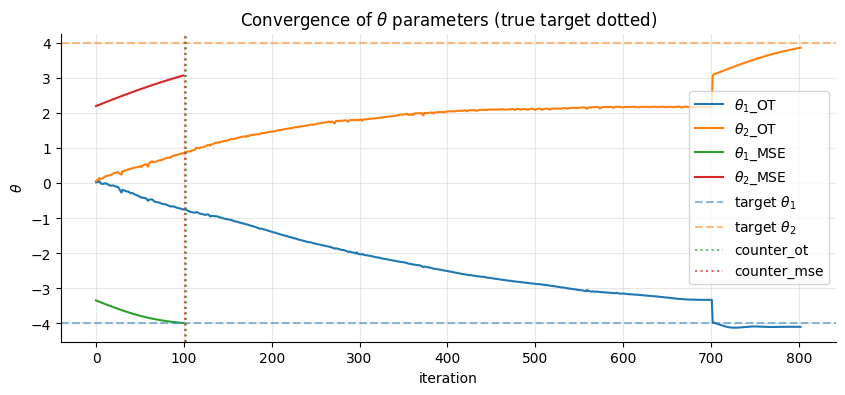

In [71]:
T_ot = np.stack(thetas_ot)  # (num_steps, n)
T = np.stack(thetas_mse)  # (num_steps, n)
plt.figure(figsize=(10, 4))
plt.plot(T_ot[:, 0], label=r"$\theta_1$_OT")
plt.plot(T_ot[:, 1], label=r"$\theta_2$_OT")
plt.plot(T[:, 0], label=r"$\theta_1$_MSE")
plt.plot(T[:, 1], label=r"$\theta_2$_MSE")
plt.axhline(y=target_mean[0].item(), color='C0', linestyle='--', label=r"target $\theta_1$", alpha=0.5)
plt.axhline(y=target_mean[1].item(), color='C1', linestyle='--', label=r"target $\theta_2$", alpha=0.5)
plt.axvline(x=counter_ot, color='C2', linestyle=':', label='counter_ot', alpha=0.7)
plt.axvline(x=counter_mse, color='C3', linestyle=':', label='counter_mse', alpha=0.7)

plt.xlabel("iteration")
plt.ylabel(r"$\theta$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Convergence of $\\theta$ parameters (true target dotted)")
plt.show()

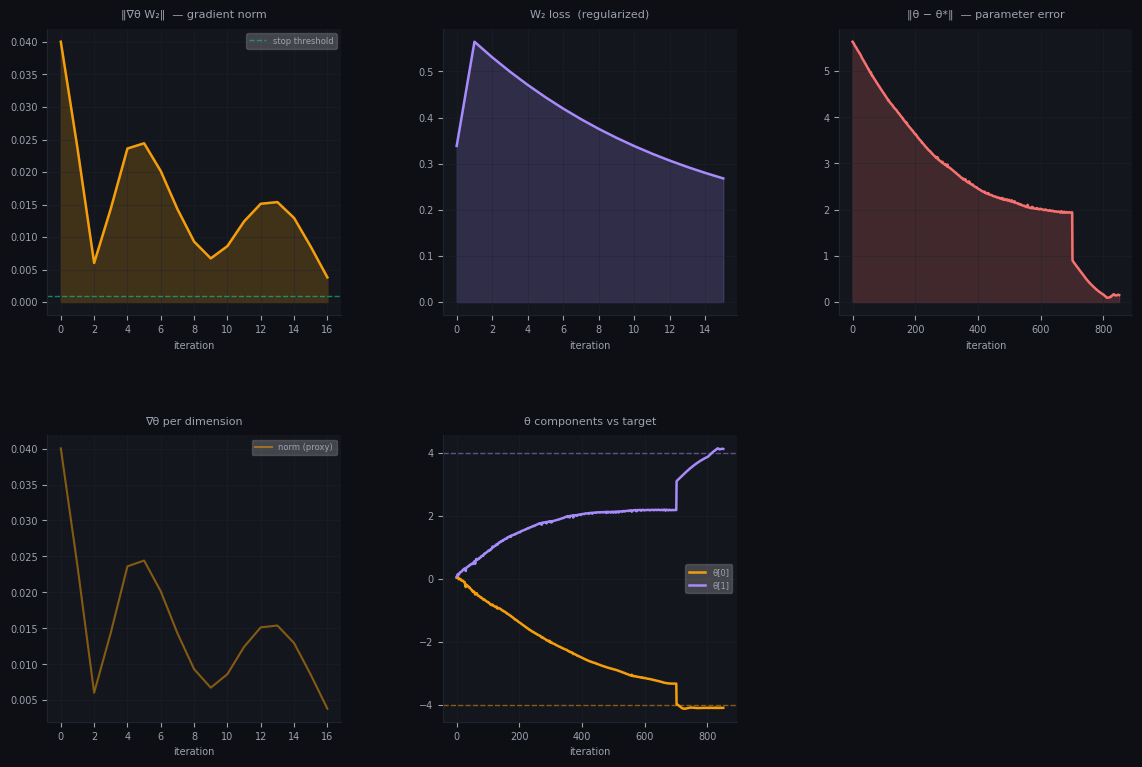

In [87]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

thetas      = np.array(thetas_ot)      # shape (T, 2)
grad_norms  = np.array(grads_norm)  # shape (T,)
# assume losses and target_mean also available
losses = np.array(ot_losses)

param_errors = np.linalg.norm(thetas - np.array(target_mean), axis=1)
# iters = np.arange(len(losses)+1)

fig = plt.figure(figsize=(14, 9), facecolor='#0d0f14')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

DARK, MID, LIGHT = '#0d0f14', '#1e2330', '#9ca3af'
AMBER, VIOLET, GREEN, RED = '#f59e0b', '#a78bfa', '#10b981', '#f87171'

def styled_ax(ax, title):
    ax.set_facecolor('#13161d')
    for spine in ax.spines.values():
        spine.set_edgecolor(MID)
    ax.tick_params(colors=LIGHT, labelsize=7)
    ax.set_title(title, color=LIGHT, fontsize=8, pad=8)
    ax.grid(color=MID, linewidth=0.5, alpha=0.6)

# --- 1. Gradient norm ---
iters = np.arange(len(grad_norms))
ax1 = fig.add_subplot(gs[0, 0])
styled_ax(ax1, '‖∇θ W₂‖  — gradient norm')
ax1.fill_between(iters, grad_norms, alpha=0.2, color=AMBER)
ax1.plot(iters, grad_norms, color=AMBER, lw=1.8)
ax1.set_xlabel('iteration', color=LIGHT, fontsize=7)
ax1.axhline(1e-3, color=GREEN, lw=1, ls='--', alpha=0.7, label='stop threshold')
ax1.legend(fontsize=6, framealpha=0.2, labelcolor=LIGHT)

# --- 2. W2 loss ---
iters = np.arange(len(losses))
ax2 = fig.add_subplot(gs[0, 1])
styled_ax(ax2, 'W₂ loss  (regularized)')
ax2.fill_between(iters, losses, alpha=0.2, color=VIOLET)
ax2.plot(iters, losses, color=VIOLET, lw=1.8)
ax2.set_xlabel('iteration', color=LIGHT, fontsize=7)

# --- 3. Parameter error ---
iters = np.arange(len(param_errors))
ax3 = fig.add_subplot(gs[0, 2])
styled_ax(ax3, '‖θ − θ*‖  — parameter error')
ax3.fill_between(iters, param_errors, alpha=0.2, color=RED)
ax3.plot(iters, param_errors, color=RED, lw=1.8)
ax3.set_xlabel('iteration', color=LIGHT, fontsize=7)

# --- 4. Per-dimension gradients ---
iters = np.arange(len(grad_norms))
ax4 = fig.add_subplot(gs[1, 0])
styled_ax(ax4, '∇θ per dimension')
# need to track grad_vecs = list of theta.grad.numpy().copy() inside loop
# ax4.plot(iters, grad_vecs[:, 0], color=AMBER,  lw=1.5, label='∂W₂/∂θ[0]')
# ax4.plot(iters, grad_vecs[:, 1], color=VIOLET, lw=1.5, label='∂W₂/∂θ[1]')
# placeholder if not tracked:
ax4.plot(iters, grad_norms, color=AMBER,  lw=1.5, alpha=0.5, label='norm (proxy)')
ax4.set_xlabel('iteration', color=LIGHT, fontsize=7)
ax4.legend(fontsize=6, framealpha=0.2, labelcolor=LIGHT)

# --- 5. θ components vs target ---
iters = np.arange(len(thetas))
ax5 = fig.add_subplot(gs[1, 1])
styled_ax(ax5, 'θ components vs target')
ax5.plot(iters, thetas[:, 0], color=AMBER,  lw=1.8, label='θ[0]')
ax5.plot(iters, thetas[:, 1], color=VIOLET, lw=1.8, label='θ[1]')
ax5.axhline(target_mean[0], color=AMBER,  lw=1, ls='--', alpha=0.5)
ax5.axhline(target_mean[1], color=VIOLET, lw=1, ls='--', alpha=0.5)
ax5.set_xlabel('iteration', color=LIGHT, fontsize=7)
ax5.legend(fontsize=6, framealpha=0.2, labelcolor=LIGHT)

plt.show()

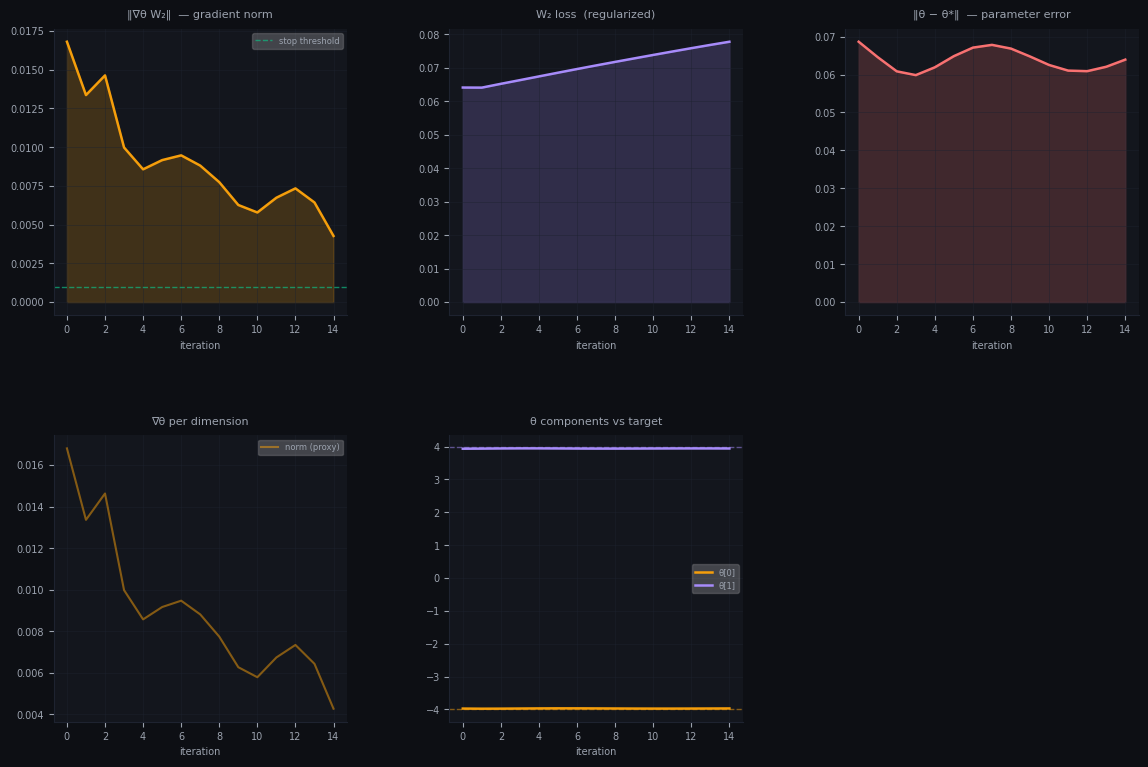

In [101]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

thetas      = np.array(thetas_skh)      # shape (T, 2)
grad_norms  = np.array(grads_norm_skh)  # shape (T,)
# assume losses and target_mean also available
losses = np.array(sinkhorn_divergence_losses)

param_errors = np.linalg.norm(thetas - np.array(target_mean), axis=1)
# iters = np.arange(len(losses)+1)

fig = plt.figure(figsize=(14, 9), facecolor='#0d0f14')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

DARK, MID, LIGHT = '#0d0f14', '#1e2330', '#9ca3af'
AMBER, VIOLET, GREEN, RED = '#f59e0b', '#a78bfa', '#10b981', '#f87171'

def styled_ax(ax, title):
    ax.set_facecolor('#13161d')
    for spine in ax.spines.values():
        spine.set_edgecolor(MID)
    ax.tick_params(colors=LIGHT, labelsize=7)
    ax.set_title(title, color=LIGHT, fontsize=8, pad=8)
    ax.grid(color=MID, linewidth=0.5, alpha=0.6)

# --- 1. Gradient norm ---
iters = np.arange(len(grad_norms))
ax1 = fig.add_subplot(gs[0, 0])
styled_ax(ax1, '‖∇θ W₂‖  — gradient norm')
ax1.fill_between(iters, grad_norms, alpha=0.2, color=AMBER)
ax1.plot(iters, grad_norms, color=AMBER, lw=1.8)
ax1.set_xlabel('iteration', color=LIGHT, fontsize=7)
ax1.axhline(1e-3, color=GREEN, lw=1, ls='--', alpha=0.7, label='stop threshold')
ax1.legend(fontsize=6, framealpha=0.2, labelcolor=LIGHT)

# --- 2. W2 loss ---
iters = np.arange(len(losses))
ax2 = fig.add_subplot(gs[0, 1])
styled_ax(ax2, 'W₂ loss  (regularized)')
ax2.fill_between(iters, losses, alpha=0.2, color=VIOLET)
ax2.plot(iters, losses, color=VIOLET, lw=1.8)
ax2.set_xlabel('iteration', color=LIGHT, fontsize=7)

# --- 3. Parameter error ---
iters = np.arange(len(param_errors))
ax3 = fig.add_subplot(gs[0, 2])
styled_ax(ax3, '‖θ − θ*‖  — parameter error')
ax3.fill_between(iters, param_errors, alpha=0.2, color=RED)
ax3.plot(iters, param_errors, color=RED, lw=1.8)
ax3.set_xlabel('iteration', color=LIGHT, fontsize=7)

# --- 4. Per-dimension gradients ---
iters = np.arange(len(grad_norms))
ax4 = fig.add_subplot(gs[1, 0])
styled_ax(ax4, '∇θ per dimension')
# need to track grad_vecs = list of theta.grad.numpy().copy() inside loop
# ax4.plot(iters, grad_vecs[:, 0], color=AMBER,  lw=1.5, label='∂W₂/∂θ[0]')
# ax4.plot(iters, grad_vecs[:, 1], color=VIOLET, lw=1.5, label='∂W₂/∂θ[1]')
# placeholder if not tracked:
ax4.plot(iters, grad_norms, color=AMBER,  lw=1.5, alpha=0.5, label='norm (proxy)')
ax4.set_xlabel('iteration', color=LIGHT, fontsize=7)
ax4.legend(fontsize=6, framealpha=0.2, labelcolor=LIGHT)

# --- 5. θ components vs target ---
iters = np.arange(len(thetas))
ax5 = fig.add_subplot(gs[1, 1])
styled_ax(ax5, 'θ components vs target')
ax5.plot(iters, thetas[:, 0], color=AMBER,  lw=1.8, label='θ[0]')
ax5.plot(iters, thetas[:, 1], color=VIOLET, lw=1.8, label='θ[1]')
ax5.axhline(target_mean[0], color=AMBER,  lw=1, ls='--', alpha=0.5)
ax5.axhline(target_mean[1], color=VIOLET, lw=1, ls='--', alpha=0.5)
ax5.set_xlabel('iteration', color=LIGHT, fontsize=7)
ax5.legend(fontsize=6, framealpha=0.2, labelcolor=LIGHT)

plt.show()

## Exercise 10 — Optimal-transport domain adaptation

> *Module 6.2.*

Setup: a binary classifier trained on labelled source data, evaluated on a target distribution that has been **rotated and shifted**. Without adaptation, accuracy collapses. OT-DA realigns source to target.

**Tasks:**
1. Generate source: `make_moons(n=300, noise=0.05)`.
2. Target: rotate by 35° and translate by $(2.5, 1.0)$.
3. Train a `LogisticRegression` on the source and evaluate on the target. Record the accuracy.
4. Apply `ot.da.SinkhornTransport(reg_e=...)` to map source onto target, train a fresh classifier on the mapped source, evaluate. Report the new accuracy.
5. Sweep $\varepsilon \in \{1e-3, 1e-2, 1e-1, 1, 10\}$ and plot accuracy vs $\varepsilon$. There's a sweet spot — find it.
6. Visualize: plot source, target, and OT-mapped source on the same axes for the best $\varepsilon$.


In [150]:
# YOUR CODE HERE
#import make_moon
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

def rotate(z, alpha):
    cos_a = torch.cos(alpha)
    sin_a = torch.sin(alpha)
    R = torch.stack([
        torch.stack([cos_a, -sin_a]),
        torch.stack([sin_a, cos_a])
    ], dim=0)
    return z @ R

def translate(z, t):
    return z + t

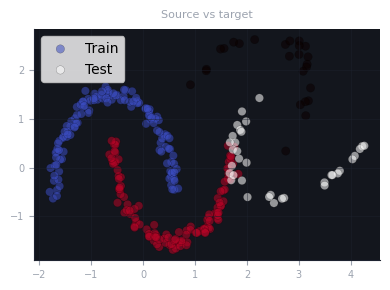

In [151]:
X, y = make_moons(n_samples=300, noise=0.05)
scaler  = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
#rotate and translate the test set
X_test = rotate(X_test, alpha = torch.tensor(35 * np.pi / 180, dtype=torch.float32))
X_test = translate(X_test, t = torch.tensor([2.5, 1.0], dtype=torch.float32))

fig, ax = plt.subplots(figsize=(4, 3))
styled_ax(ax, "Source vs target")

ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm",
           alpha=0.55, edgecolors="k", linewidths=0.2, label="Train")
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="hot",
           alpha=0.55, edgecolors="k", linewidths=0.2, label="Test")

ax.legend()   # if LIGHT is in scope from your diagnostics cell
plt.tight_layout()
plt.show()



In [152]:
#Fit the LogisticRegressor on the train set
model = LogisticRegression()
model.fit(X_train, y_train)
#evaluate the model on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8666666666666667


/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:902: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


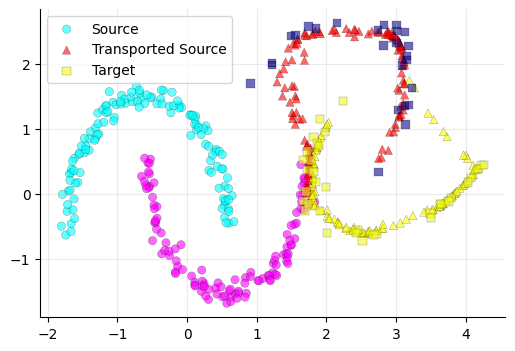

In [153]:
transport = ot.da.SinkhornTransport(reg_e = 2e-1, max_iter = 3000)
transport.fit(Xs = X_train, Xt= X_test)
source_transported = transport.transform(X_train)
#plot the source and target
# Use clearly distinctive colormaps and styles for clarity
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='cool', label='Source', alpha=0.6, marker='o', edgecolors='k', linewidths=0.2)
plt.scatter(source_transported[:, 0], source_transported[:, 1], c=y_train, cmap='autumn', label='Transported Source', alpha=0.6, marker='^', edgecolors='k', linewidths=0.2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='plasma', label='Target', alpha=0.6, marker='s', edgecolors='k', linewidths=0.2)
plt.legend()
plt.show()


In [154]:
#fit the logistic regressor on the transported source
model = LogisticRegression()
model.fit(source_transported, y_train)
#evaluate the model on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8333333333333334


/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:902: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:902: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:902: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:902: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  war

Text(0.5, 1.0, 'Accuracy vs Regularization Parameter')

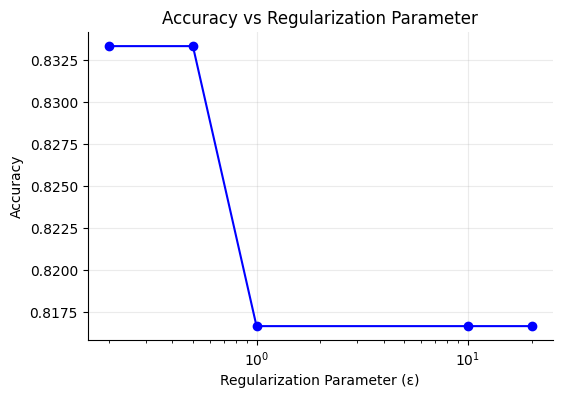

In [163]:
eps_values = [ 2e-1, 5e-1, 1, 10, 20]
accuracies = []
for eps in eps_values:
    transport = ot.da.SinkhornTransport(reg_e = eps, max_iter = 7000, method = 'sinkhorn_log')
    transport.fit(Xs = X_train, Xt= X_test)
    source_transported = transport.transform(X_train)
    model = LogisticRegression()
    model.fit(source_transported, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
plt.plot(eps_values, accuracies, marker='o', linestyle='-', color='b')
plt.xscale('log')
plt.xlabel('Regularization Parameter (ε)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Regularization Parameter')

## Exercise 11 — Gromov–Wasserstein for unsupervised alignment

> *Module 6.3 — closest to your neural-decoding work.*

You have two recordings from different subjects, both encoding the same task. Neurons are unlabelled across subjects (no shared identity). Standard hyperalignment requires paired stimuli; here we don't assume that.

GW-OT minimizes pairwise-distance distortion:

$$\mathrm{GW}^2 = \min_{\pi \in \Pi(p, q)} \sum_{i,j,k,l} \bigl(C^X_{ij} - C^Y_{kl}\bigr)^2 \pi_{ik} \pi_{jl}.$$

**Tasks (synthetic neural-data sandbox):**
1. Generate a "ground-truth" latent trajectory $Z \in \mathbb{R}^{T \times d}$ in $d = 4$ latent dimensions for $T = 80$ time bins. Use a smooth random curve.
2. Subject A: $X^A = Z W^A + \epsilon^A$ where $W^A \in \mathbb{R}^{4 \times 30}$ and noise. (30-neuron recording.)
3. Subject B: $X^B = Z W^B + \epsilon^B$ with $W^B \in \mathbb{R}^{4 \times 25}$. (25-neuron recording, fewer neurons, different mixing.)
4. Compute pairwise distance matrices $C^A = \mathrm{cdist}(X^A, X^A)$ and $C^B$. (Distance between time bins, in the **neural** space of each subject.)
5. Run `ot.gromov.gromov_wasserstein(C^A, C^B, p, q)` to align time bins across subjects.
6. Evaluate: the alignment plan should put mass on the diagonal (time bin $t$ in A ↔ time bin $t$ in B). Compute alignment accuracy as fraction of mass on the diagonal.
7. Compare with a naive baseline: align by sorting time bins on the first PC.
8. **Stretch:** can you make this fail? Try giving subject B a global time-reversal or a permutation. Does GW pick it up? What does this tell you about the symmetries GW is invariant to?


In [196]:
# YOUR CODE HERE — neural alignment sandbox
from scipy.ndimage import gaussian_filter1d

d,T,T1, T2 = 4, 80, 30, 25
Z_raw = rng.standard_normal((T,d))#.cumsum()
Z = gaussian_filter1d(Z_raw,sigma=0.8,axis=0) # (T,d)
W_a, W_b = rng.random(size=(d,T1)), rng.random(size=(d,T2)) # (d,N1/N2)
eps_a, eps_b = np.zeros((T,T1)), np.zeros((T,T2))
X_a, X_b = Z @ W_a + eps_a, Z @ W_b + eps_b # (T,N1/N2)
C_a = cdist(X_a,X_a)
C_b = cdist(X_b,X_b)
p , q = np.ones(T)/T, np.ones(T)/T
res = ot.gromov.entropic_gromov_wasserstein(C_a,C_b,p,q)
ot_accuracy = np.sum(res.diagonal())/np.sum(res)
print(f"Gromov-WS accuracy : {ot_accuracy}")

from sklearn.decomposition import PCA
pca_a = PCA(n_components=1)
pca_b = PCA(n_components=1)
pc1_a = pca_a.fit_transform(X_a).ravel()
pc1_b = pca_b.fit_transform(X_b).ravel()
# Align using the first PC by sorting the time bins based on their first principal component value.
idx_a = np.argsort(pc1_a)
idx_b = np.argsort(pc1_b)

# Build a permutation matrix for the naive alignment (identity after sorting)
perm_matrix = np.zeros((T, T))
for i in range(T):
    perm_matrix[idx_a[i], idx_b[i]] = 1

# The accuracy is fraction of permutation matrix mass on the diagonal
naive_accuracy = np.sum(np.diag(perm_matrix)) / np.sum(perm_matrix)
print(f"Naive (first PC sort) accuracy: {naive_accuracy}")

# Hints:
#   - Generate Z with cumulative random walk + smoothing (e.g., scipy.ndimage.gaussian_filter1d).
#   - Use ot.gromov.entropic_gromov_wasserstein for stability if the unregularized version is unstable.
#   - p = q = uniform(T).


/Users/mohamedbaha/Library/Python/3.9/lib/python/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Gromov-WS accuracy : 0.8934118949408996
Naive (first PC sort) accuracy: 0.4875


## Exercise 12 — A 1-D WGAN, hand-rolled

> *Module 6.1.*

Strip a Wasserstein GAN to its essence. Source $z \sim \mathcal{N}(0, 1)$. True target $\mathbb{P}_r = \mathcal{N}(\mu^\star, 1)$ with $\mu^\star = 3$.

- **Generator:** $g_\theta(z) = z + \theta$ (one parameter).
- **Critic:** $f_w(x) = w_1 x + w_0$, with weights clamped to $[-1, 1]$ after each update (poor man's Lipschitz constraint).

The WGAN minimax (with K-R) is

$$\min_\theta \max_{\|f_w\|_{\mathrm{Lip}} \leq 1} \;\mathbb{E}_{x \sim \mathbb{P}_r}[f_w(x)] - \mathbb{E}_{z}[f_w(g_\theta(z))].$$

**Tasks:**
1. Train with batch size 256: 5 critic updates per generator update, both with SGD, learning rate $1\mathrm{e}{-2}$.
2. Plot $\theta$ over training. It should converge to $\mu^\star = 3$.
3. Plot the critic loss (which estimates $W_1$) over training. Compare to the true $W_1(\mathcal{N}(\theta, 1), \mathcal{N}(3, 1)) = |\theta - 3|$.
4. **Replace weight clipping with a gradient penalty** (Gulrajani 2017): on samples $\hat x = \alpha x_r + (1-\alpha) x_g$ with $\alpha \sim U[0,1]$, add $\lambda (|\nabla_{\hat x} f_w(\hat x)| - 1)^2$ to the critic loss. Compare convergence speed and stability with weight clipping.
5. **What goes wrong if you train the critic too little per generator update?** Try 1 critic step per generator step. Comment.


Training time: 3.85 seconds


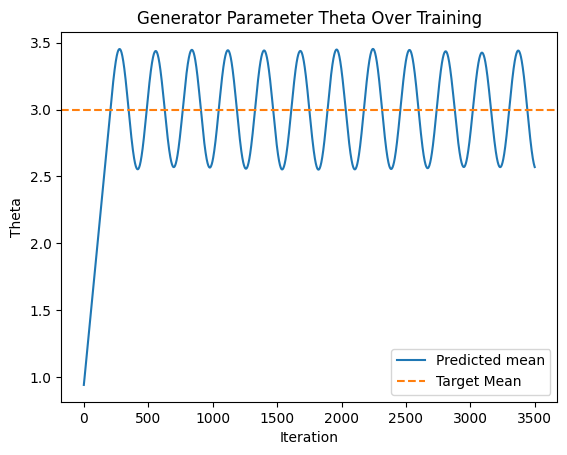

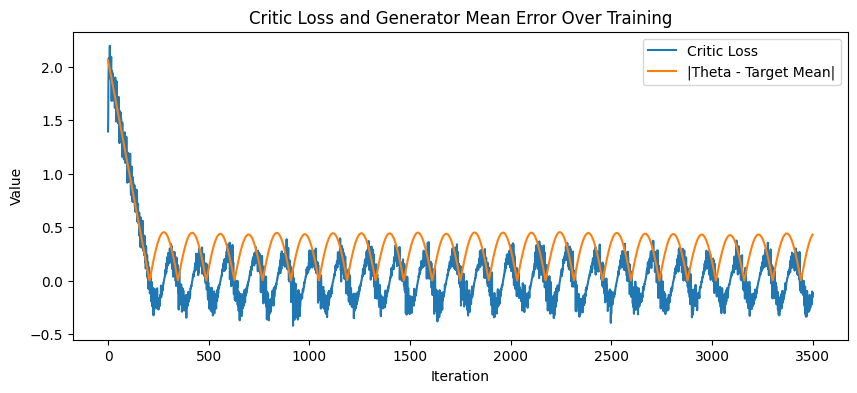

In [68]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

batch_size = 256
n_iterMax = 3500
n_critic = 5
lr = 1e-2
target_mean = 3.0

# Initial parameters for generator and critic
theta = torch.rand(1, requires_grad=True)
w0 = torch.rand(1, requires_grad=True)
w1 = torch.rand(1, requires_grad=True)

optim_c = optim.SGD([w0, w1], lr=lr)
optim_g = optim.SGD([theta], lr=lr)
thetas, critics = [], []

start_time = time.time()  # Start timing

for _ in range(n_iterMax):
    for _ in range(n_critic):
        # Sample real data from N(3, 1)
        x_target = torch.normal(mean=target_mean, std=1, size=(batch_size,))
        # Sample latent variable
        z = torch.randn(batch_size)
        # Critic outputs for real and fake samples
        f_real = w1 * x_target + w0
        # Note: theta detached to isolate generator from critic update
        x_fake = z + theta.detach()
        f_fake = w1 * x_fake + w0
        # Critic loss (maximize difference)
        loss_c = -(f_real.mean() - f_fake.mean())
        optim_c.zero_grad()
        loss_c.backward()
        optim_c.step()
        # Clamp weights for 1-Lipschitz constraint
        with torch.no_grad():
            w1.clamp_(-1, 1)
            w0.clamp_(-1, 1)
    critics.append(-loss_c.item())
    # Generator update (maximize critic response)
    # Do not detach theta here, generator trained via theta
    z = torch.randn(batch_size)
    x_fake = z + theta
    f_fake = w1.detach() * x_fake + w0.detach()
    loss_g = -f_fake.mean()
    optim_g.zero_grad()
    loss_g.backward()
    optim_g.step()
    thetas.append(theta.detach().item())

end_time = time.time()  # End timing
elapsed_time = end_time - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

plt.plot(np.array(thetas), label="Predicted mean", color="tab:blue")
plt.axhline(target_mean, color='tab:orange', linestyle='--', label='Target Mean')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Theta')
plt.title('Generator Parameter Theta Over Training')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(critics, label="Critic Loss")
plt.plot(np.abs(np.array(thetas) - target_mean), label="|Theta - Target Mean|")
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Critic Loss and Generator Mean Error Over Training')
plt.legend()
plt.show()

Total training time for WGAN with gradient penalty: 10.13 seconds


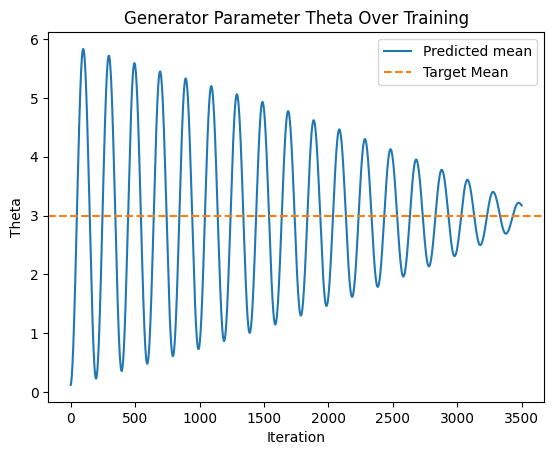

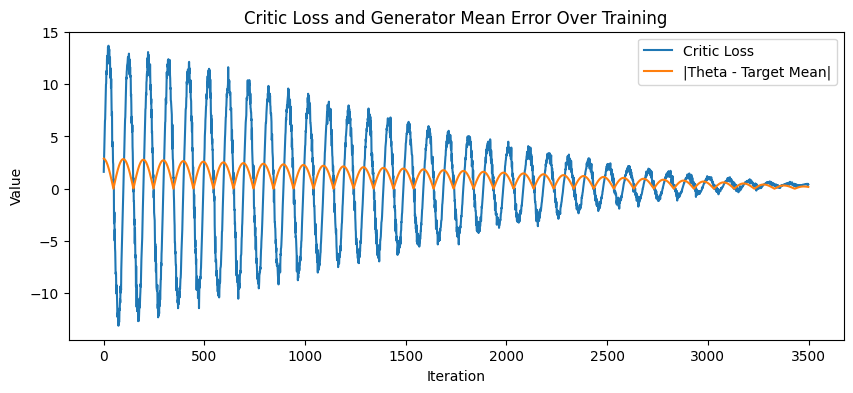

In [65]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import time

batch_size = 256
n_iterMax = 3500
n_critic = 10
lr = 1e-2
target_mean = 3.0
lam = 0.4

# Initial parameters for generator and critic
theta = torch.rand(1, requires_grad=True)
w0 = torch.rand(1, requires_grad=True)
w1 = torch.rand(1, requires_grad=True)

optim_c = optim.SGD([w0, w1], lr=lr)
optim_g = optim.SGD([theta], lr=lr)
thetas, critics = [], []

start_time = time.time()  # Start timing

for _ in range(n_iterMax):
    for _ in range(n_critic):
        # Sample real data from N(3, 1)
        x_target = torch.normal(mean=target_mean, std=1, size=(batch_size,))
        # Sample latent variable
        z = torch.randn(batch_size)
        # Critic outputs for real and fake samples
        f_real = w1 * x_target + w0
        # Note: theta detached to isolate generator from critic update
        x_fake = z + theta.detach()
        f_fake = w1 * x_fake + w0
        alph = torch.rand(batch_size, device=x_target.device)
        x_hat = alph * x_target + (1 - alph) * x_fake
        x_hat.requires_grad_()
        f_hat = w1 * x_hat + w0
        gp = torch.autograd.grad(
            outputs=f_hat.mean(),
            inputs=x_hat,
            create_graph=True,
            # retain_graph=True,
            only_inputs=True
        )[0]
        gp = gp.norm(p=2)
        # Critic loss with gradient penalty
        loss_c = -(f_real.mean() - f_fake.mean()) - lam * ((gp - 1)**2).mean()
        optim_c.zero_grad()
        loss_c.backward()
        optim_c.step()
    critics.append(-loss_c.item())
    # Generator update (maximize critic response)
    # Do not detach theta here, generator trained via theta
    z = torch.randn(batch_size)
    x_fake = z + theta
    f_fake = w1.detach() * x_fake + w0.detach()
    loss_g = -f_fake.mean()
    optim_g.zero_grad()
    loss_g.backward()
    optim_g.step()
    thetas.append(theta.detach().item())

end_time = time.time()  # End timing
elapsed = end_time - start_time
print(f"Total training time for WGAN with gradient penalty: {elapsed:.2f} seconds")

plt.plot(np.array(thetas), label="Predicted mean", color="tab:blue")
plt.axhline(target_mean, color='tab:orange', linestyle='--', label='Target Mean')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Theta')
plt.title('Generator Parameter Theta Over Training')
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(critics, label="Critic Loss")
plt.plot(np.abs(np.array(thetas) - target_mean), label="|Theta - Target Mean|")
plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Critic Loss and Generator Mean Error Over Training')
plt.legend()
plt.show()

## After you finish

If you've made it here, you have hand-implemented the discrete Kantorovich LP, two flavours of Sinkhorn, the Sinkhorn divergence, and applied OT to domain adaptation, GW alignment, and a tiny WGAN. That is more OT than most ML researchers ever write.

Suggested next steps:
- **Reproduce a paper figure.** Pick one from Sasaki et al. (2025, GW-OT for neuroscience) or Courty et al. (2017, OT-DA) and reproduce a single figure end-to-end.
- **Try OTT-JAX or geomloss.** GPU implementations matter once you scale past $\sim$10k samples.
- **Read Peyré & Cuturi** chapters 4 (entropic) and 9 (variational Wasserstein) once the algorithms feel familiar.
- **Apply to your own data.** If you have any kind of distribution-comparison problem in your decoding work — across sessions, across animals, across recording modalities — try GW-OT on it. The barrier to entry is two lines of POT.

Good luck.
